## TCGA Dataset - Exploratory Data Analysis

In [18]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
tcga_df_unfil = pd.read_csv('tcga_df_unfil.csv', index_col=0, low_memory=False)

In [20]:
tcga_df_unfil.head()

,A1BG,A1CF,A2BP1,A2LD1,A2M,A2M-AS1,A2ML1,A4GALT,A4GNT,AAA1,...,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22,Mutated,Mutation_Type,Protein_Conseq,Functional_Conseq,Tumor_Type
Patient_ID,,,,,,,,,,,,,,,,,,,,,
TCGA-OR-A5J1-01,16.3305,0.0000,17.2911,182.3920,10373.70,221.8830,54.7550,190.6820,0.0000,0.0,...,648.415,1841.020,1157.540,596.062,715.658,0,WT,NaN,NaN,adrenocortical
TCGA-OR-A5J2-01,9.5987,0.0000,5.6368,239.1580,9844.91,101.6680,0.0000,198.8990,0.0000,0.0,...,1166.020,3059.990,1895.990,801.637,581.801,1,DEL,Frame_Shift_Del,NaN,adrenocortical
TCGA-OR-A5J3-01,20.7377,0.5925,8.8876,138.8830,7201.84,70.5673,1.7775,75.2481,2.3700,0.0,...,806.399,2655.610,1482.450,437.269,126.796,0,WT,NaN,NaN,adrenocortical
TCGA-OR-A5J5-01,1696.6600,1.5492,6.1967,63.9349,2939.04,123.7030,49.5740,374.9030,0.7746,0.0,...,553.834,2367.930,1140.200,512.781,855.151,1,SNP,Missense_Mutation,deleterious(0),adrenocortical
TCGA-OR-A5J6-01,600.1620,0.0000,4.4709,237.3520,9586.96,89.6406,1.1177,1556.4200,0.5589,0.0,...,795.812,708.071,796.371,475.587,288.370,0,WT,NaN,NaN,adrenocortical


In [21]:
print(f"{tcga_df_unfil.shape[0]}: nr patients")
print(f"{tcga_df_unfil.shape[1]}: nr genes")

4235: nr patients
20512: nr genes


Check first for empty rows and columns, and if there are any, remove them.

In [22]:
gene_data = tcga_df_unfil.iloc[:, :-5]
gene_data.head()

,A1BG,A1CF,A2BP1,A2LD1,A2M,A2M-AS1,A2ML1,A4GALT,A4GNT,AAA1,...,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22
Patient_ID,,,,,,,,,,,,,,,,,,,,,
TCGA-OR-A5J1-01,16.3305,0.0000,17.2911,182.3920,10373.70,221.8830,54.7550,190.6820,0.0000,0.0,...,146.9740,20.6532,351.585,1050.910,0.4803,648.415,1841.020,1157.540,596.062,715.658
TCGA-OR-A5J2-01,9.5987,0.0000,5.6368,239.1580,9844.91,101.6680,0.0000,198.8990,0.0000,0.0,...,438.4640,57.1735,279.023,2979.870,31.4052,1166.020,3059.990,1895.990,801.637,581.801
TCGA-OR-A5J3-01,20.7377,0.5925,8.8876,138.8830,7201.84,70.5673,1.7775,75.2481,2.3700,0.0,...,190.1940,39.6978,495.334,914.827,0.5925,806.399,2655.610,1482.450,437.269,126.796
TCGA-OR-A5J5-01,1696.6600,1.5492,6.1967,63.9349,2939.04,123.7030,49.5740,374.9030,0.7746,0.0,...,840.4340,17.8156,206.042,890.782,11.6189,553.834,2367.930,1140.200,512.781,855.151
TCGA-OR-A5J6-01,600.1620,0.0000,4.4709,237.3520,9586.96,89.6406,1.1177,1556.4200,0.5589,0.0,...,63.1508,12.8537,117.919,894.730,7.8240,795.812,708.071,796.371,475.587,288.370


In [23]:
def empty_cols(df):
    nulldf=[]
    for col in df.iloc[:, :-5].columns:
        if df[col].sum()==0:
            nulldf.append(col)
    return nulldf
cols_to_drop = empty_cols(gene_data)
print(f'There are {len(cols_to_drop)} Empty columns:')
print(cols_to_drop)

nan_cols = tcga_df_unfil.columns[tcga_df_unfil.isna().all()]
print(f"\n{len(nan_cols)} columns are entirely NaN")
print(nan_cols.tolist())
tcga_df_unfil = tcga_df_unfil.dropna(axis=1, how='all')

There are 229 Empty columns:
['HBII-52-24', 'HBII-52-27', 'HBII-52-28', 'HBII-52-45', 'KRTAP22-1', 'PRAMEF3', 'PRR20B', 'PRR20D', 'RNU5E', 'RNY4', 'RNY5', 'SNAR-A4', 'SNAR-C2', 'SNAR-H', 'SNORA11C', 'SNORA35', 'SNORD102', 'SNORD104', 'SNORD105', 'SNORD105B', 'SNORD109B', 'SNORD11', 'SNORD110', 'SNORD111', 'SNORD111B', 'SNORD113-1', 'SNORD113-2', 'SNORD113-4', 'SNORD113-5', 'SNORD113-6', 'SNORD113-7', 'SNORD113-9', 'SNORD114-1', 'SNORD114-10', 'SNORD114-11', 'SNORD114-12', 'SNORD114-13', 'SNORD114-14', 'SNORD114-15', 'SNORD114-16', 'SNORD114-17', 'SNORD114-18', 'SNORD114-19', 'SNORD114-2', 'SNORD114-20', 'SNORD114-21', 'SNORD114-22', 'SNORD114-23', 'SNORD114-24', 'SNORD114-25', 'SNORD114-26', 'SNORD114-27', 'SNORD114-28', 'SNORD114-29', 'SNORD114-3', 'SNORD114-30', 'SNORD114-31', 'SNORD114-4', 'SNORD114-5', 'SNORD114-6', 'SNORD114-7', 'SNORD114-8', 'SNORD114-9', 'SNORD115-1', 'SNORD115-10', 'SNORD115-11', 'SNORD115-14', 'SNORD115-16', 'SNORD115-17', 'SNORD115-2', 'SNORD115-20', 'SNORD11

In [24]:
tcga_df_unfil = tcga_df_unfil.drop(columns=cols_to_drop)

In [25]:
## drop duplicate columns and rows
tcga_df_unfil = tcga_df_unfil.drop_duplicates()
tcga_df_unfil = (tcga_df_unfil.T.drop_duplicates()).T

In [26]:
print(tcga_df_unfil.shape)
tcga_df_unfil.head()

(4235, 20283)


,A1BG,A1CF,A2BP1,A2LD1,A2M,A2M-AS1,A2ML1,A4GALT,A4GNT,AAA1,...,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22,Mutated,Mutation_Type,Protein_Conseq,Functional_Conseq,Tumor_Type
Patient_ID,,,,,,,,,,,,,,,,,,,,,
TCGA-OR-A5J1-01,16.3305,0.0,17.2911,182.392,10373.7,221.883,54.755,190.682,0.0,0.0,...,648.415,1841.02,1157.54,596.062,715.658,0,WT,NaN,NaN,adrenocortical
TCGA-OR-A5J2-01,9.5987,0.0,5.6368,239.158,9844.91,101.668,0.0,198.899,0.0,0.0,...,1166.02,3059.99,1895.99,801.637,581.801,1,DEL,Frame_Shift_Del,NaN,adrenocortical
TCGA-OR-A5J3-01,20.7377,0.5925,8.8876,138.883,7201.84,70.5673,1.7775,75.2481,2.37,0.0,...,806.399,2655.61,1482.45,437.269,126.796,0,WT,NaN,NaN,adrenocortical
TCGA-OR-A5J5-01,1696.66,1.5492,6.1967,63.9349,2939.04,123.703,49.574,374.903,0.7746,0.0,...,553.834,2367.93,1140.2,512.781,855.151,1,SNP,Missense_Mutation,deleterious(0),adrenocortical
TCGA-OR-A5J6-01,600.162,0.0,4.4709,237.352,9586.96,89.6406,1.1177,1556.42,0.5589,0.0,...,795.812,708.071,796.371,475.587,288.37,0,WT,NaN,NaN,adrenocortical


Then we replace the NaN values in the gene expression table to integer values, to address potential issues in the dataset construction

In [27]:
gene_data = tcga_df_unfil.iloc[:, :-5]
metadata = tcga_df_unfil.iloc[:, -5:]
gene_data = gene_data.fillna(0.0)

C:\Users\Utente\AppData\Local\Temp\ipykernel_18960\3220018176.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  gene_data = gene_data.fillna(0.0)


### EDA

We now proceed with a more extensive Exploratory Data Analysis, in which the main aim is to investigate the main properties of the dataset.

As duplicate rows and columns were deleted, and the non-expressed genes were dropped, we are left with the data of
- 4235 patients (samples) on the rows 'Patient_ID'
- 20283 genes (features) ('Hugo_Symbol')

In [28]:
print(tcga_df_unfil.shape)
tcga_df_unfil.head()

(4235, 20283)


,A1BG,A1CF,A2BP1,A2LD1,A2M,A2M-AS1,A2ML1,A4GALT,A4GNT,AAA1,...,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22,Mutated,Mutation_Type,Protein_Conseq,Functional_Conseq,Tumor_Type
Patient_ID,,,,,,,,,,,,,,,,,,,,,
TCGA-OR-A5J1-01,16.3305,0.0,17.2911,182.392,10373.7,221.883,54.755,190.682,0.0,0.0,...,648.415,1841.02,1157.54,596.062,715.658,0,WT,NaN,NaN,adrenocortical
TCGA-OR-A5J2-01,9.5987,0.0,5.6368,239.158,9844.91,101.668,0.0,198.899,0.0,0.0,...,1166.02,3059.99,1895.99,801.637,581.801,1,DEL,Frame_Shift_Del,NaN,adrenocortical
TCGA-OR-A5J3-01,20.7377,0.5925,8.8876,138.883,7201.84,70.5673,1.7775,75.2481,2.37,0.0,...,806.399,2655.61,1482.45,437.269,126.796,0,WT,NaN,NaN,adrenocortical
TCGA-OR-A5J5-01,1696.66,1.5492,6.1967,63.9349,2939.04,123.703,49.574,374.903,0.7746,0.0,...,553.834,2367.93,1140.2,512.781,855.151,1,SNP,Missense_Mutation,deleterious(0),adrenocortical
TCGA-OR-A5J6-01,600.162,0.0,4.4709,237.352,9586.96,89.6406,1.1177,1556.42,0.5589,0.0,...,795.812,708.071,796.371,475.587,288.37,0,WT,NaN,NaN,adrenocortical


Starting from a statistical analysis:

In [29]:
stats = gene_data.describe()
stats

,A1BG,A1CF,A2BP1,A2LD1,A2M,A2M-AS1,A2ML1,A4GALT,A4GNT,AAA1,...,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22
count,4235.000000,4235.000000,4235.000000,4235.000000,4235.000000,4235.000000,4235.000000,4235.000000,4235.000000,4235.000000,...,4235.000000,4235.000000,4235.000000,4235.000000,4235.000000,4235.000000,4235.000000,4235.000000,4235.000000,4235.000000
mean,105.916400,33.673541,72.243726,105.563884,11151.725104,25.024101,1452.046044,561.217443,14.528616,0.549583,...,945.554960,53.704105,433.581024,1130.067468,50.814642,864.952398,4353.843988,1316.901468,769.760644,173.605898
std,154.345617,81.971201,371.055329,72.863843,13938.540433,26.496234,4911.019902,771.240457,103.627662,2.563668,...,676.359439,29.431987,249.070397,359.853751,86.897671,378.352013,2533.859524,591.175573,365.851581,580.543813
min,0.932293,-0.269975,-0.330564,2.309700,162.329239,-0.394651,-0.413655,11.869579,-0.280487,-0.570901,...,12.699900,-0.465130,0.634500,256.015474,-0.402069,46.019981,202.934000,173.645000,76.459534,-0.351035
25%,26.757489,0.000000,0.000000,54.777364,3931.458320,10.340050,1.013423,116.208500,0.000000,0.000000,...,449.949000,31.421100,278.411000,893.986823,0.884879,606.891000,2615.705000,901.622000,562.410556,7.453500
50%,58.431300,0.000000,0.466300,89.905700,7571.980000,17.901700,26.562000,269.439943,0.437300,0.000000,...,829.182000,49.430100,389.266288,1078.160000,6.685200,794.924065,3838.640000,1225.890000,720.872000,21.574600
75%,128.571500,1.367336,6.598943,138.051000,13795.950000,30.214550,464.168500,671.526000,1.315200,0.026234,...,1289.790000,70.678670,524.275500,1308.205000,69.002471,1040.085000,5412.430000,1636.545414,903.031500,82.534140
max,2752.200000,857.969493,6153.670000,664.746065,289140.000000,362.645000,84482.200000,9397.390000,2331.288762,64.842200,...,7018.710000,273.711000,3220.500000,4530.223381,900.610000,3256.710000,23934.200000,6773.996334,8174.370000,12327.900000


The min expression count of genes is not constant, oscillating from high values (over 100 in some cases) to negative values for other genes.

This evident volatility can raise questions about the heterogeneity of the data, as it could reflect the presence of different subgroups or clusters within the dataset, or may suggest that outliers or extreme values in the dataset have a significant impact on the summary statistics.\ It might also indicate issues such as data quality problems, measurement errors, or changing data collection methods.

We then check for the presence of zero-variance genes in the dataset: if any, they will be considered biologically non-essential for the analysis, as they might be fundamental for a cell's existence without being relevant to discriminate between cases of mutation / healthy cells.

In [30]:
stats.T['std'][stats.T['std']==0]

Series([], Name: std, dtype: float64)

This could be due to inter-patient variability, which can be enhanced also due to the presence of different cancer types. Also, RNA-Seq is inherently noisy; even lowly expressed genes usually have small differences in expression due to batch effects, sequencing depth, or normalization errors.

We then discard genes with a low *coefficient of variation* (CV), where $CV = \frac{\sigma}{\mu}$ standard deviation of gene expression across samples over mean expression across samples.

This metric can be used to identify genes carrying little discriminative power, since genes with nearly constant expression across all patients cannot help distinguish phenotypes, like TP53 mutation status (they are biologically necessary but uninformative for classification).

Also, a low cv can be caused by genes with high mean expression relative to the standard deviation. A gene that is always high across both mutant and wild-type samples contributes no discriminative power. So, despite being highly expressed, the gene barely changes across samples, hence low relative variability.

This could lead to models favoring genes with high absolute expression over informative variation. 

To perform a more reliable filtering, we separate the dataset of gene expression in two sub-tables: the ones where tp53 is labeled as mutated, and those where tp53 is not.. We choose the 10th quantile as threshold for a light filtering, and then we merge the dataset back into a filtered one that will be used for model selection and evaluation.

In [ ]:
tcga_mut = tcga_df_unfil[tcga_df_unfil['Mutated'] == 1]
tcga_wt  = tcga_df_unfil[tcga_df_unfil['Mutated'] == 0]

expr_mut = tcga_mut.iloc[:, :-5].fillna(0.0)
expr_wt  = tcga_wt.iloc[:, :-5].fillna(0.0)

print(f"Mutated samples: {len(expr_mut)}, WT samples: {len(expr_wt)}")

cv_mut = expr_mut.std() / expr_mut.mean()
cv_wt  = expr_wt.std() / expr_wt.mean()



# Use max CV to preserve genes variable in either group
cv_combined = pd.concat([cv_mut, cv_wt], axis=1)
cv_combined.columns = ['mut', 'wt']
cv_max = cv_combined.max(axis=1)

threshold = cv_max.quantile(0.10)
filtered_genes = cv_max[cv_max > threshold].index

# Filtered expression matrices
expr_mut_filt = expr_mut[filtered_genes]
expr_wt_filt  = expr_wt[filtered_genes]

expr_filtered = pd.concat([expr_mut_filt, expr_wt_filt])
metadata_filt = tcga_df_unfil.loc[expr_filtered.index].iloc[:, -5:]
tcga_filt = pd.concat([expr_filtered, metadata_filt], axis=1)

C:\Users\Utente\AppData\Local\Temp\ipykernel_18960\316476361.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  expr_mut = tcga_mut.iloc[:, :-5].fillna(0.0)
C:\Users\Utente\AppData\Local\Temp\ipykernel_18960\316476361.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  expr_wt  = tcga_wt.iloc[:, :-5].fillna(0.0)


Mutated samples: 1570, WT samples: 2665


We have hence discarded around 4000 of the least expressed genes in the dataset.

In [91]:
print(f"before filtering: {tcga_df_unfil.shape}")
print(f"after filtering: {tcga_filt.shape}")

before filtering: (4235, 20283)
after filtering: (4235, 18255)


##### Sparsity
Analyzing sparsity (i.e., the proportion of zero or near-zero gene expression values) can reveal important biological and technical patterns, especially when comparing TP53-mutated vs wild-type samples.

For instance, a higher number of zero-expression genes could indicate gene silencing (eg due to TP53 loss-of-function), tissue-specific expression loss, or lower transcriptional activity.

First, we quantify sparsity per gene and per sample.

1. Gene-level sparsity: How many samples express each gene?
    - $\text{sparsity gene} = \frac{\text{count of zeros across samples}}{\text{total samples}}$

2. Sample-level sparsity: How many genes are expressed?
    - $\text{sparsity sample} = \frac{\text{count of zeros across genes}}{\text{total genes}}$

**Sample-Level Sparsity:** *For each sample, how many genes are not expressed*

It indicates how transcriptionally active each sample is.
If TP53-mut samples lead to more genes being sparsely expressed, it may suggest loss of broad gene programs.

If sparsity is lower in TP53-mut samples, we expect that maybe a specific set of genes are turned on (oncogenic signaling)

C:\Users\Utente\AppData\Local\Temp\ipykernel_18960\3949836888.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Sparsity', data=sparsity_df, palette=['darkred', 'darkblue'])


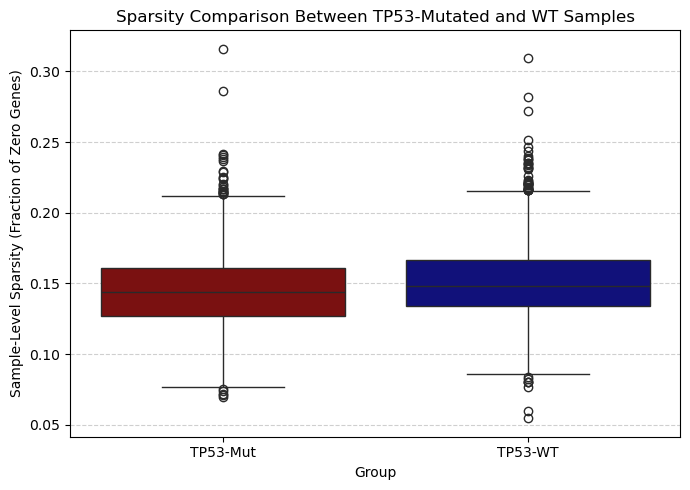

In [ ]:
binary_mut = (expr_mut_filt > 0).astype(int)
binary_wt  = (expr_wt_filt  > 0).astype(int)

sample_sparsity_mut = 1 - binary_mut.sum(axis=1) / expr_mut_filt.shape[1]
sample_sparsity_wt  = 1 - binary_wt.sum(axis=1)  / expr_wt_filt.shape[1]


sparsity_df = pd.DataFrame({
    'Sparsity': pd.concat([sample_sparsity_mut, sample_sparsity_wt], ignore_index=True),
    'Group': ['TP53-Mut'] * len(sample_sparsity_mut) + ['TP53-WT'] * len(sample_sparsity_wt)
})

plt.figure(figsize=(7, 5))
sns.boxplot(x='Group', y='Sparsity', data=sparsity_df, palette=['darkred', 'darkblue'])
plt.ylabel('Sample-Level Sparsity (Fraction of Zero Genes)')
plt.title('Sparsity Comparison Between TP53-Mutated and WT Samples')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Here we see the presence of outliers, which suggests some possibly mixed subtype behavior, and a median shift.

Mutations in the TP53 gene can have different effects, but generally, they contribute to uncontrolled cell proliferation and can lead to tumor growth. While some mutations can lead to cell death or senescence, the main effect of TP53 mutations is to disrupt the normal regulatory processes of the cell cycle and DNA damage response, which can lead to an increase in cell proliferation.

Thhe behavior of TP53-mut samples, that may upregulate stress-response, proliferation, DNA repair, or inflammatory genes — can justify it leading to lower sparsity.

It’s possible the WT group includes slower-growing, more specialized cells → expressing fewer genes, while clones in the TP53-mut group may activate different programs → increasing the number of detected genes overall.



<Axes: ylabel='None'>

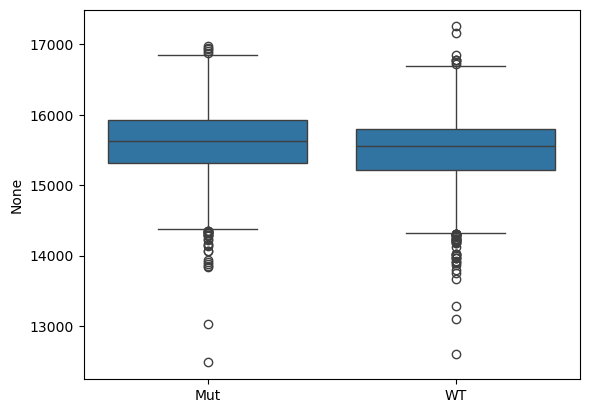

In [92]:
total_expressed = (tcga_filt.iloc[:,:-5] > 0).sum(axis=1)
sns.boxplot(x=['Mut' if i in expr_mut_filt.index else 'WT' for i in tcga_filt.iloc[:,:-5].index],
            y=total_expressed)

The same result is observed when it comes to gene expression.

To be sure, we perform a Mann-Whitney-U test to test the null hypothesis that the sample-level sparsity values in the TP53-mutated and TP53-WT groups come from the same distribution (so, that there is no significant difference in gene expression coverage between groups).

In [64]:
from scipy.stats import mannwhitneyu

u_stat, p_val = mannwhitneyu(sample_sparsity_mut, sample_sparsity_wt, alternative='two-sided')
print(f"U = {u_stat}, p = {p_val:.4g}")

U = 1830739.0, p = 1.055e-11


Since p<0.05, we reject the null hypothesis, and acknowledge that there is a statistically significant difference in sample-level sparsity between TP53-mutated and wild-type samples. We can therefore conclude that TP53-mutated samples express significantly more genes on average than wild-type samples.

**Gene-level sparsity:** *For each gene, in how many samples is it not expressed?*

This indicator is informative about how ubiquitous or specific a gene’s expression is across the cohort.

Since we are working with a highly expressive dataset, we expect Most genes are expressed in most samples → gene-level sparsity is low (close to 0)


C:\Users\Utente\AppData\Local\Temp\ipykernel_18960\2773494270.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Sparsity', data=sparsity_df, palette=['darkred', 'darkblue'])


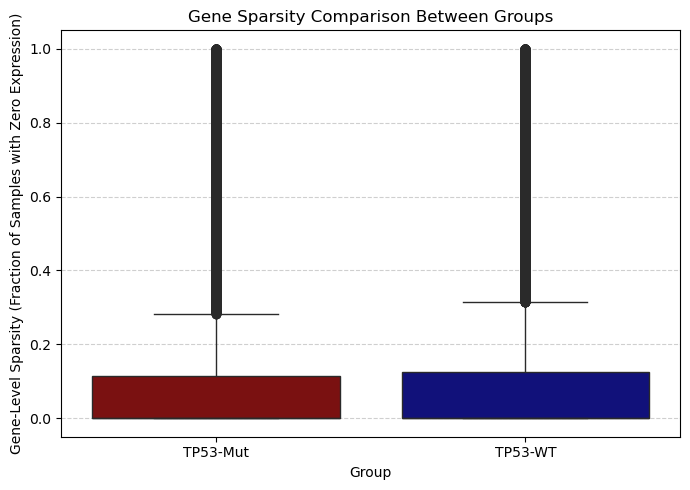

In [65]:
gene_sparsity_mut = 1 - binary_mut.sum(axis=0) / len(expr_mut_filt)
gene_sparsity_wt  = 1 - binary_wt.sum(axis=0)  / len(expr_wt_filt)

sparsity_df = pd.DataFrame({
    'Sparsity': pd.concat([gene_sparsity_mut, gene_sparsity_wt], ignore_index=True),
    'Group': ['TP53-Mut'] * len(gene_sparsity_mut) + ['TP53-WT'] * len(gene_sparsity_wt)
})

plt.figure(figsize=(7, 5))
sns.boxplot(x='Group', y='Sparsity', data=sparsity_df, palette=['darkred', 'darkblue'])
plt.ylabel('Gene-Level Sparsity (Fraction of Samples with Zero Expression)')
plt.title('Gene Sparsity Comparison Between Groups')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

On average, genes are expressed in both groups very broadly. Even the compressed gene-level boxplots seem a natural result of most genes being broadly expressed.

The difference in which genes are expressed or how strongly may be more important than the overall count of expressed genes.

To confirm our observations, we could check for differences in the distribution in which genes are expressed, or how strongly.

Instead of comparing all genes' sparsity, we tried focusing on genes with large sparsity shifts and visualized gene sparsity histograms.

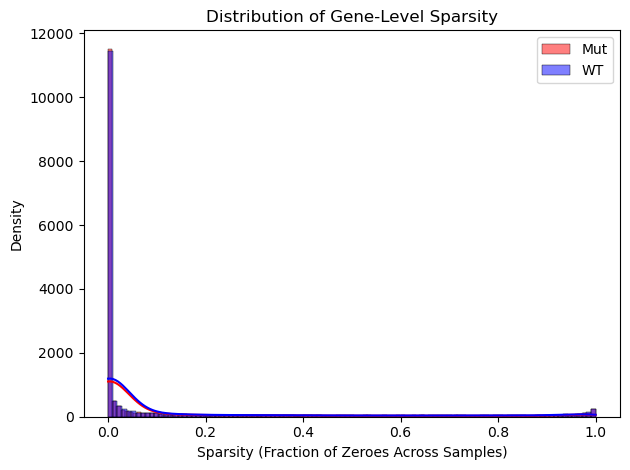

In [66]:
sns.histplot(gene_sparsity_mut, color='red', label='Mut', kde=True)
sns.histplot(gene_sparsity_wt,  color='blue', label='WT', kde=True)
plt.title('Distribution of Gene-Level Sparsity')
plt.xlabel('Sparsity (Fraction of Zeroes Across Samples)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

- X-axis: Gene-level sparsity
    - 0.0 → gene is expressed in all samples in that group
    - 1.0 → gene is expressed in none of the samples in that group

- Y-axis: Density
    - Represents How many genes fall into that level of sparsity

In this case, we observe that there is little to no difference in overall gene-level sparsity. This indicates that most genes are expressed in both groups at similar frequencies, and in particular, with the peak frequency attained at 0 sparsity (hence high expression rate).

The plot also shows "rug plots” (or tick marks), which are vertical lines representing some of the data points (genes) drawn at its exact sparsity value on the x-axis. They help you see the underlying distribution of the actual data points that the smooth KDE curve is based on.

In [67]:
sparsity_diff = gene_sparsity_wt - gene_sparsity_mut
top_up_in_mut = sparsity_diff.sort_values(ascending=True).head(20)
top_down_in_mut = sparsity_diff.sort_values(ascending=False).head(20)

print("Top_Up, Top_Down")
for x, y in zip(top_up_in_mut.index.to_list(), top_down_in_mut.index.to_list()):
    print(f"{x},  {y}")

Top_Up, Top_Down
CST9,  C1orf105
FRMPD2,  TINAG
MAPT-AS1,  ZNF280A
SCGB1D2,  SMPX
SLC7A13,  MAGEA5
GPR139,  KRTAP5-5
PRTN3,  SLC6A19
FCN2,  UNC93A
CIB3,  CPN1
NXNL1,  PRSS41
CST9L,  PRDM13
DEFB132,  UGT1A10
MAPT-IT1,  PDX1
CYP4A22,  TAS2R38
MIR205HG,  STRA8
SCGB2A2,  PLA2G4E
C9orf106,  NKX2-3
NCRNA00160,  AKR1C4
PYDC1,  MAGEA3
C14orf180,  KRTAP4-1


**Highly expressed Genes**

In [96]:
column_means = tcga_filt.iloc[:,:-5].mean()
col_mut_means = expr_mut_filt.mean()
col_wt_means = expr_wt_filt.mean()

most_expressed = pd.DataFrame({'df': column_means.sort_values(ascending=False).index.to_list()[:200],
                               'mut':col_mut_means.sort_values(ascending=False).index.to_list()[:200],
                               'wt': col_wt_means.sort_values(ascending=False).index.to_list()[:200]})

most_expressed.head()


,df,mut,wt
0,COL1A1,KRT5,COL1A1
1,EEF1A1,KRT14,EEF1A1
2,KRT5,COL1A1,GAPDH
3,GAPDH,GAPDH,KRT5
4,KRT14,EEF1A1,GFAP


First, we see that many of the most expressed genes are common between df, appear to be remarkable housekeeper genes.

- ACTB) β-actin, cytoskeletal component (classic hk)
- GAPDH) glycolysis enzyme (so hk too)
- COL1A1) structural integrity --> also, often overexpressed in cancer, so is not directly a transcriptional target
- EEF1A1) eucaryotic translation and elongation --> hk

- LDHA, ALDOA, ENO1, PKM2 --> common in cancer cells, but not pathway-specific to tp53

this manual query is not satisfying - the most expressed genes are either fundamental for the cell's survival, or are extremely overexpressed and common in cancer cells.

since the dataset contains only genes sampled from patients affected by tumors, and since some types of cancer trigger the overexpression of more genes, the expression becomes too noisy to be taken into account for now.


#### Target Genes

Target genes are genes whose expression is directly regulated by a specific transcription factor or signaling pathway.

In the context of TP53, their target genes are those genes that the TP53 (the p53 protein) binds to and activates or represses their transcription.

To be called a bona-fide target gene, a gene must be such that: p53 binds to its promoter or enhancer region, its expression changes in response to p53 activation (e.g. after DNA damage). It usually increases. Also, this change is lost in p53-deficient cells, confirming dependence.

We have seen that a gene can be highly expressed in a TP53-mut sample without being a TP53 target For instance, GAPDH or COL1A1 can be upregulated in TP53-mutated cancers due to metabolic shifts or EMT — but p53 doesn't bind to their promoters.

Given a list of bona-fide target genes, we can now explicitly inspect how many and which tp53 target genes are present in the dataset, first as the most expressed ones, and also in the entire dataset.

In [82]:
all_top_genes = set(most_expressed['df']).union(
                most_expressed['mut']
            ).union(
                most_expressed['wt']
            )

hk_genes = ['RPL13A', 'RPLP0', 'ACTB', 'GAPDH', 'B2M', 'HPRT1', 'TBP', 'PGK1', 'PPIA', 'SDHA',
    'GUSB', 'HMBS', 'RPS18', 'RPL19', 'RPS27A', 'EEF1A1', 'RPS3', 'RPL3', 'RPL4',
    'RPL8', 'RPS6', 'RPL5', 'RPS24', 'RPL7A', 'RPS12', 'RPL10', 'RPL18A', 'RPS23', 
    'RPS19', 'RPL6', 'RPL9', 'RPS8', 'RPS4X', 'RPS27', 'RPL27', 'RPS2', 'RPS5',
    'TUBA1B', 'TUBB', 'CYC1', 'COX4I1', 'ATP5B', 'ATP5F1', 'MRPL12', 'NDUFA1', 
    'NDUFB4', 'NDUFS1', 'TFRC', 'YWHAZ', 'ALDOA', 'ENO1', 'LDHA', 'MDH1', 'PKM',
    'SDHB', 'TPI1', 'TXN', 'VIM', 'RRN18S', 'ACTB', 'GAPDH', 'PGK1', 'PPIA', 'RPL13A', 'RPLP0', 'ARBP', 'B2M', 'YWHAZ', 'SDHA','TRFC', 'GUSB', 'HMBS', 'HPRT1', 'TBP']
tp53_target = ['CDKN1A', 'ABCA12', 'NTPCR', 'PGPEP1', 'RNF19B', 'LCE1E', 'EPN3', 'SCN4B', 'ARVCF',
               'FCHO2', 'PANK2', 'TMEM8B', 'RRM2B', 'ANKRA2', 'ORAI3', 'PLCL2', 'SAC3D1', 'LIMK2', 'FBXO32',
               'SCRIB', 'BHLHE40', 'FCHSD2', 'PAQR7', 'TP53', 'MDM2', 'CCNG1', 'PRKAB1', 'PMAIP1', 'SYTL1', 'LRP1',
               'FHL2', 'SEMA3B', 'BMP7', 'FLRT2', 'PCBP4', 'TP53I11', 'SUSD6', 'CYFIP2', 'PTP4A1', 'PRDM1', 'TNFRSF10A',
               'MCC', 'HES2', 'SLC25A45', 'BORCS7', 'GBE1', 'PERP', 'TRAK1', 'DF15', 'DRAM1', 'SESN2', 'RAP2B', 'TNFRSF10D',
               'NUPR1', 'KCNN4', 'SLC44A5', 'BTBD10', 'GPC1', 'PLLP', 'TRIP6', 'BTG2', 'FBXO22', 'SLC30A1', 'RRAD', 'TSPAN11',
               'PARD6G', 'KLHDC7A', 'SLC4A11', 'BTG3', 'HES1', 'POU3F1', 'TSGA10 DDB2', 'ISCU', 'SPATA18', 'ZNF219', 'VWCE',
               'PHPT1', 'LMNA', 'SLC9A1', 'C17orf89', 'HRAS', 'PPFIBP1', 'UNC5B', 'GADD45A', 'PHLDA3', 'TGFA', 'ZNF337',
               'DDIT4', 'PIDD1', 'MLF2', 'STAT3', 'CAPN2', 'HSD17B3', 'PPM1J', 'UQCC1', 'PLK3', 'SERPINB5', 'TLR3', 'ACTA2',
               'RAD51C', 'PML', 'MR1', 'STK17A', 'CASP6', 'ICOSLG', 'PPP4R3A', 'VDR', 'TIGAR', 'SERTAD1', 'TM7SF3', 'EDN2',
               'SERPINE1', 'PTPRE', 'MYO6', 'STX6', 'CATSPERG', 'IGFBP7', 'PTAFR', 'YPEL3', 'RPS27L', 'TRAF4', 'TMEM68',
               'ALOX5', 'TNFAIP8', 'PVRL4', 'NEFL', 'TP73', 'CAV1', 'IL1B', 'RALGDS', 'ZNF195', 'TNFRSF10B', 'TRIM22',
               'WDR63', 'ARHGEF3', 'TSKU', 'RETSAT', 'NKAIN4', 'TRIM32', 'CCNK', 'ISYNA1', 'RBM38', 'ZNF385A TRIAP1', 'CES2',
               'ZNF561', 'CERS5', 'PCNA', 'REV3L', 'PCLO', 'TRIM38', 'CFLAR', 'JAG1', 'RGL1', 'ZNF488', 'ZMAT3', 'CMBL', 'ZNF79',
               'DDR1', 'ACYP2', 'RNASE7', 'PDE4C', 'TRIM5', 'CGB7', 'KRT8', 'RGS20', 'BAX', 'FBXW7', 'ASCC3', 'DHRS3', 'APAF1',
               'SFN', 'PGAP1', 'TYMSOS', 'CHST14', 'KSR1', 'RHOC', 'PGF', 'HSPA4L', 'ACER2', 'DUSP14', 'APOBEC3H', 'TNFRSF10C',
               'PLCXD2', 'AKAP9', 'COBLL1', 'LACC1', 'RPS19', 'POLH', 'KITLG', 'ANXA4', 'E2F7', 'BCL2L1', 'TRIML2', 'PLEKHF1',
               'CCDC51', 'CPEB2', 'LPXN', 'SARS', 'PPM1D', 'SLC12A4', 'APOBEC3C', 'EPS8L2', 'BCL6', 'VCAN', 'PLTP', 'CDH8',
               'CPSF4', 'LRPAP1', 'SCIN', 'SULF2', 'ATF3', 'ASTN2', 'FAM210B', 'BLCAP', 'ADCK3', 'PLXNB1', 'DUSP11', 'DNAJB2',
               'MFAP3L', 'SCN3B', 'XPC', 'BBC3', 'CD82', 'GLS2', 'C17orf82', 'AK3', 'PLXNB2', 'GCC2', 'DOCK8', 'MKNK2', 'SDC4',
               'AEN', 'CCDC90B', 'CDIP1', 'GPX1', 'COL7A1', 'ALDH1A3', 'PRKAB2', 'METTL8', 'DUSP5', 'MON2', 'SDPR', 'BLOC1S2', 
               'DYRK3', 'CPE', 'GRHL3', 'CPEB4', 'BBS2', 'PRKX', 'PPP1R3C', 'DUSP7', 'MRPL49', 'SMAD3', 'FAS', 'EDA2R', 'CSF1',
               'HHAT', 'CSNK1G1', 'BTG1', 'PRODH', 'STEAP3', 'EBI3', 'MYBPHL', 'SNX2', 'GPR87', 'EPHA2', 'DCP1B', 'IGDCC4', 'DGKA',
               'CEL', 'PTPRU', 'ABHD4', 'EFNB1', 'MYLK', 'SOCS4', 'NINJ1', 'FAM13C', 'ENC1', 'IKBIP', 'FAM49A', 'CLCA2', 'RGMA', 'ABTB2', 'EI24', 'MYOF', 'TAB3', 'PLK2', 'FAM198B', 'FOSL1', 'LAPTM5', 'FAM84B', 'CLDN1', 'RGS16', 'ADGRG1', 'EML2', 'NFKBIA', 'TCAIM', 'PSTPIP2', 'FAM212B', 'FUCA1', 'MAST4', 'GNAI1', 'CLP1', 'RND3', 'AIFM2', 'ENPP2', 'NHLH2', 'TEP1', 'SESN1', 'FDXR', 'IER5', 'MICALL1', 'INPP1', 'CROT', 'RNF144B', 'AMOTL1', 'ETV7', 'NLRP1', 'TET2', 'TP53I3', 'LIF', 'PADI4', 'NOTCH1', 'ITGA3', 'CYP4F3', 'S100A2', 'AMZ2', 'FAM196A', 'NYNRIN', 'TEX9', 'TP53INP1', 'NADSYN1', 'PANK1', 'RABGGTA', 'KRT15', 'DAPK1', 'SCN2A', 'ARC', 'FAM98C', 'P3H2', 'TMEM63B']

In [83]:
def target_in_df(target_list, df_list):
    final_list = []
    for gene in df_list:
        if gene in target_list:
            final_list.append(gene)
    return final_list

In [97]:
print('200 most expressed in mut and wt')
mut_200 = target_in_df(tp53_target, most_expressed['mut'])
print(mut_200)
wt_200 = target_in_df(tp53_target, most_expressed['wt'])
print(wt_200)
print(len(mut_200), len(wt_200))

print('\ntarget genes present in mut and wt')
mut_tg = target_in_df(tp53_target, expr_mut_filt.columns.to_list())
wt_tg = target_in_df(tp53_target, expr_wt_filt.columns.to_list())
print(mut_tg)
print(wt_tg)
print(len(mut_tg), len(wt_tg))

200 most expressed in mut and wt
['KRT8', 'RPS19', 'PERP', 'SFN', 'S100A2', 'LMNA']
['KRT8', 'RPS19', 'SFN', 'PERP', 'DDR1', 'LMNA', 'S100A2', 'LRP1']
6 8

target genes present in mut and wt
['ABCA12', 'ABHD4', 'ABTB2', 'ACER2', 'ACTA2', 'ACYP2', 'AEN', 'AIFM2', 'AK3', 'AKAP9', 'ALDH1A3', 'ALOX5', 'AMOTL1', 'AMZ2', 'ANKRA2', 'ANXA4', 'APAF1', 'APOBEC3C', 'APOBEC3H', 'ARC', 'ARHGEF3', 'ARVCF', 'ASCC3', 'ASTN2', 'ATF3', 'BAX', 'BBC3', 'BBS2', 'BCL2L1', 'BCL6', 'BHLHE40', 'BLCAP', 'BLOC1S2', 'BMP7', 'BTG1', 'BTG2', 'BTG3', 'C17orf82', 'C17orf89', 'CAPN2', 'CASP6', 'CATSPERG', 'CAV1', 'CCDC51', 'CCDC90B', 'CCNG1', 'CD82', 'CDH8', 'CDKN1A', 'CEL', 'CES2', 'CFLAR', 'CGB7', 'CHST14', 'CLCA2', 'CLDN1', 'CMBL', 'COBLL1', 'COL7A1', 'CPE', 'CPEB2', 'CPEB4', 'CPSF4', 'CROT', 'CSF1', 'CSNK1G1', 'CYFIP2', 'CYP4F3', 'DAPK1', 'DCP1B', 'DDIT4', 'DDR1', 'DGKA', 'DHRS3', 'DNAJB2', 'DOCK8', 'DRAM1', 'DUSP11', 'DUSP14', 'DUSP5', 'DUSP7', 'DYRK3', 'E2F7', 'EBI3', 'EDA2R', 'EDN2', 'EFNB1', 'EML2', 'ENC1', 'E

A few considerations:

1. Wild-type p53 is not silent
    - Even without strong stress, wild-type p53 is always present at low levels and can activate basal expression of target genes like PERP, SFN, or CDKN1A.
    - If the WT tumors experience mild hypoxia, DNA replication stress, or oncogene activation, p53 might be partially activated.

2. p53-independent expression of some targets
    - Not all "target genes" are exclusively regulated by p53. Many have multiple regulators.


3. Some genes may be misclassified as "targets"
    - Large TP53 target lists can include also weaker or context-dependent targets, whose expression may not rely entirely on p53

In [101]:
from scipy.stats import mannwhitneyu

u, p = mannwhitneyu(
    tcga_filt[tcga_filt['Mutated'] == 1]['PERP'],
    tcga_filt[tcga_filt['Mutated'] == 0]['PERP'],
    alternative='two-sided'
)
print(f"PERP: U={u}, p={p:.4g}")

PERP: U=2364271.5, p=1.401e-12


C:\Users\Utente\AppData\Local\Temp\ipykernel_18960\2092834513.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


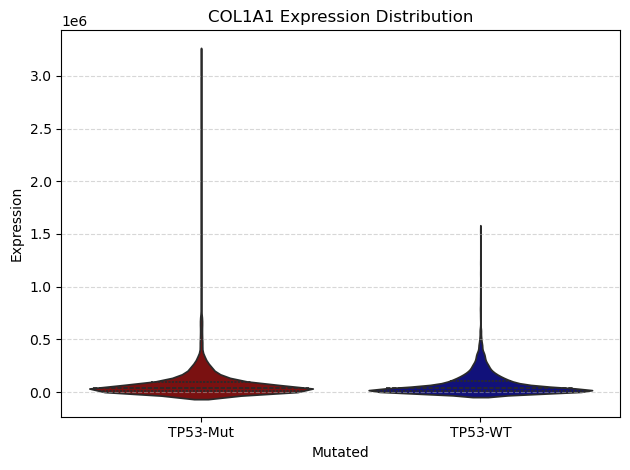

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

for gene in ['COL1A1']:#['CDKN1A']:#, 'PERP', 'PUMA', 'GADD45A']: 
    if gene in tcga_filt.columns:
        sns.violinplot(
            x=tcga_filt['Mutated'].map({1: 'TP53-Mut', 0: 'TP53-WT'}),
            y=tcga_filt[gene],
            palette=['darkred', 'darkblue'],
            inner='quartile'
        )
        plt.title(f'{gene} Expression Distribution')
        plt.ylabel('Expression')
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

**In TP53-Mutated samples:**

If the target gene is strongly activated by p53, and mutant p53 is non-functional, we could expect lower expression (left-heavy violin).
However, some TP53 targets may be upregulated due to other pathways, or gain-of-function mutant p53. This can happen especially in aggressive cancers.

So the distribution may widen, showing high expression in a subset of tumors and low in others → possibly bimodal.

the gene selected above was shown since it is responsible for cell cycle arrest. it is commonly high in wt, and low in mut.

C:\Users\Utente\AppData\Local\Temp\ipykernel_18960\1297512461.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


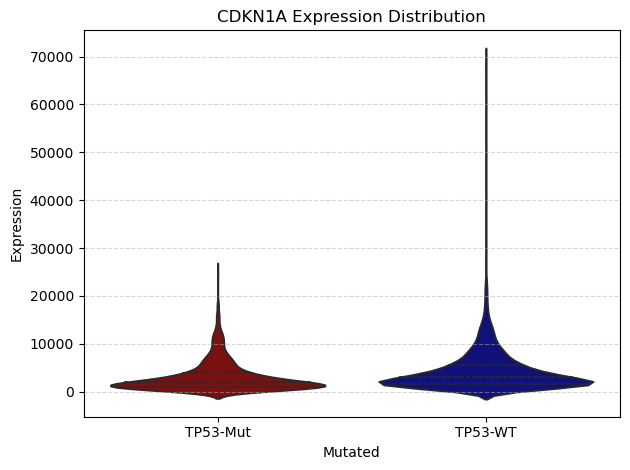

In [115]:
for gene in ['CDKN1A']:#['CDKN1A']:#, 'PERP', 'PUMA', 'GADD45A']: 
    if gene in tcga_filt.columns:
        sns.violinplot(
            x=tcga_filt['Mutated'].map({1: 'TP53-Mut', 0: 'TP53-WT'}),
            y=tcga_filt[gene],
            palette=['darkred', 'darkblue'],
            inner='quartile'
        )
        plt.title(f'{gene} Expression Distribution')
        plt.ylabel('Expression')
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

Not p53 target but often high in Mut due to EMT or stromal changes

from *https://www.genomics-online.com/resources/16/5049/housekeeping-genes/* we selected a short list of housekeeping genes.

#### Correlation

1. Tumor-specific correlation.
Patients of the same tumor type have high correlation in gene expression.
This suggests that tumor biology dominates gene expression patterns more than TP53 status (at first glance).

In [126]:
tumors = set(tcga_filt['Tumor_Type'].to_list())
print(tumors)

{'colorectal', 'glioblastoma', 'head_neck_sq', 'stomach', 'brain', 'adrenocortical', 'bladder', 'cervical_sq', 'esophageal', 'breast_invasive'}


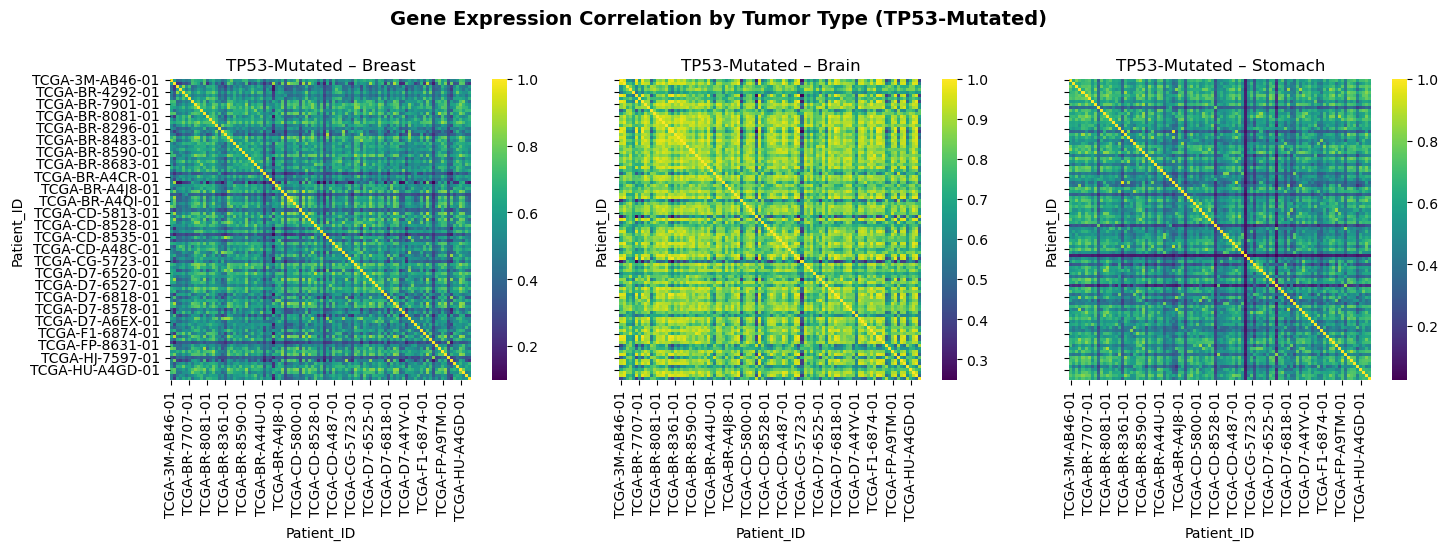

In [135]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

# Plot 1: Breast Invasive
sns.heatmap(
    tcga_filt[(tcga_filt['Mutated'] == 1) & (tcga_filt['Tumor_Type'] == 'breast_invasive')]
    .iloc[:, :-5].T.iloc[:, :100].corr(),
    ax=axes[0], cmap='viridis', fmt='.1f', square=True
)
axes[0].set_title('TP53-Mutated – Breast')

# Plot 2: Adrenocortical
sns.heatmap(
    tcga_filt[(tcga_filt['Mutated'] == 1) & (tcga_filt['Tumor_Type'] == 'brain')]
    .iloc[:, :-5].T.iloc[:, :100].corr(),
    ax=axes[1], cmap='viridis', fmt='.1f', square=True
)
axes[1].set_title('TP53-Mutated – Brain')

# Plot 3: Stomach
sns.heatmap(
    tcga_filt[(tcga_filt['Mutated'] == 1) & (tcga_filt['Tumor_Type'] == 'stomach')]
    .iloc[:, :-5].T.iloc[:, :100].corr(),
    ax=axes[2], cmap='viridis', fmt='.1f', square=True
)
axes[2].set_title('TP53-Mutated – Stomach')

# Figure-level title
fig.suptitle('Gene Expression Correlation by Tumor Type (TP53-Mutated)', fontsize=14, weight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

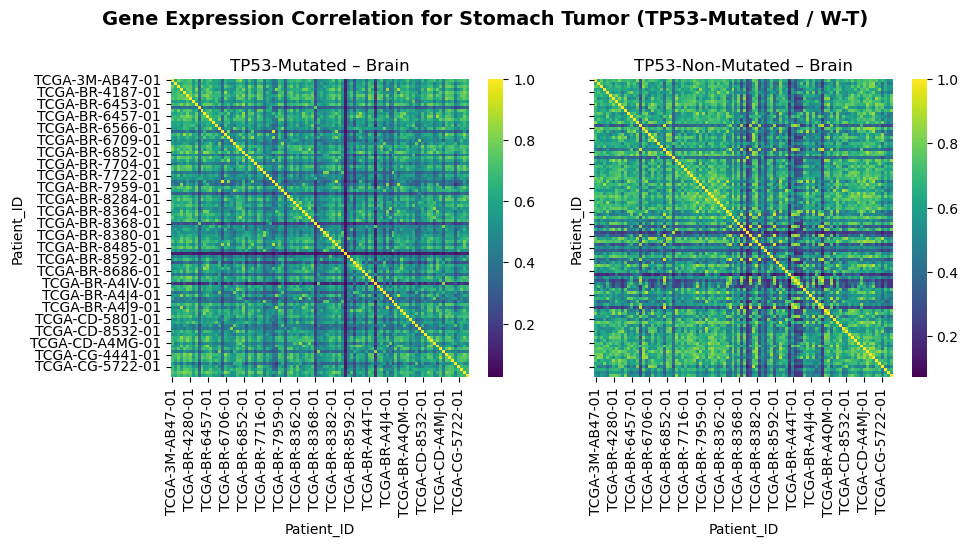

In [137]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

sns.heatmap(
    tcga_filt[(tcga_filt['Mutated'] == 1) & (tcga_filt['Tumor_Type'] == 'stomach')]
    .iloc[:, :-5].T.iloc[:, :100].corr(),
    ax=axes[0], cmap='viridis', fmt='.1f', square=True
)
axes[0].set_title('TP53-Mutated – Brain')

sns.heatmap(
    tcga_filt[(tcga_filt['Mutated'] == 0) & (tcga_filt['Tumor_Type'] == 'stomach')]
    .iloc[:, :-5].T.iloc[:, :100].corr(),
    ax=axes[1], cmap='viridis', fmt='.1f', square=True
)
axes[1].set_title('TP53-Non-Mutated – Brain')

fig.suptitle('Gene Expression Correlation for Stomach Tumor (TP53-Mutated / W-T)', fontsize=14, weight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Wild-type TP53 leads to more balanced transcriptional regulation, less variability, and no strong "driver" signature. Might actually act as a stabilizer here, since there are no mutations

Bright points represent patients that happen to be similar, but not due to an overriding mutation-induced program.

Dark lines might be associated to outlier patients, or to different mutations of tp53.

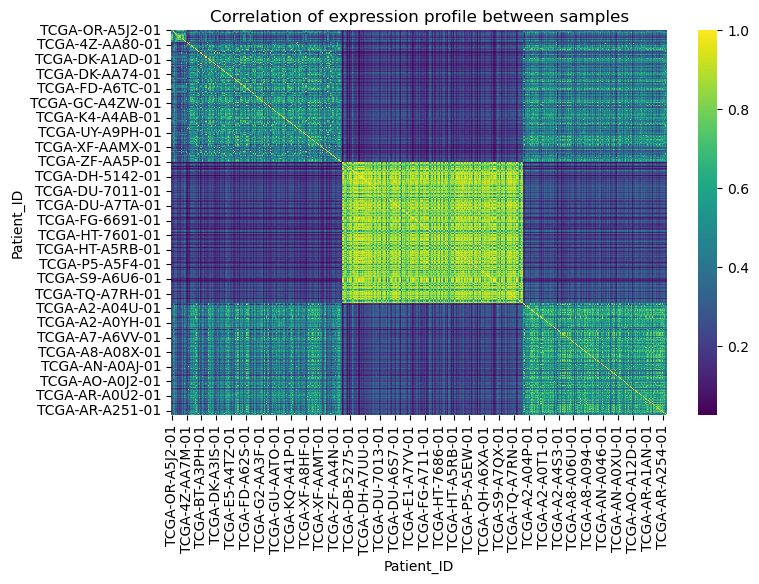

In [138]:
plt.figure(figsize = (8,5))
plt.title('Correlation of expression profile between samples')
sns.heatmap(tcga_filt.iloc[:,:-5].T.iloc[:, :500].corr(), cmap = 'viridis', fmt ='.01f');

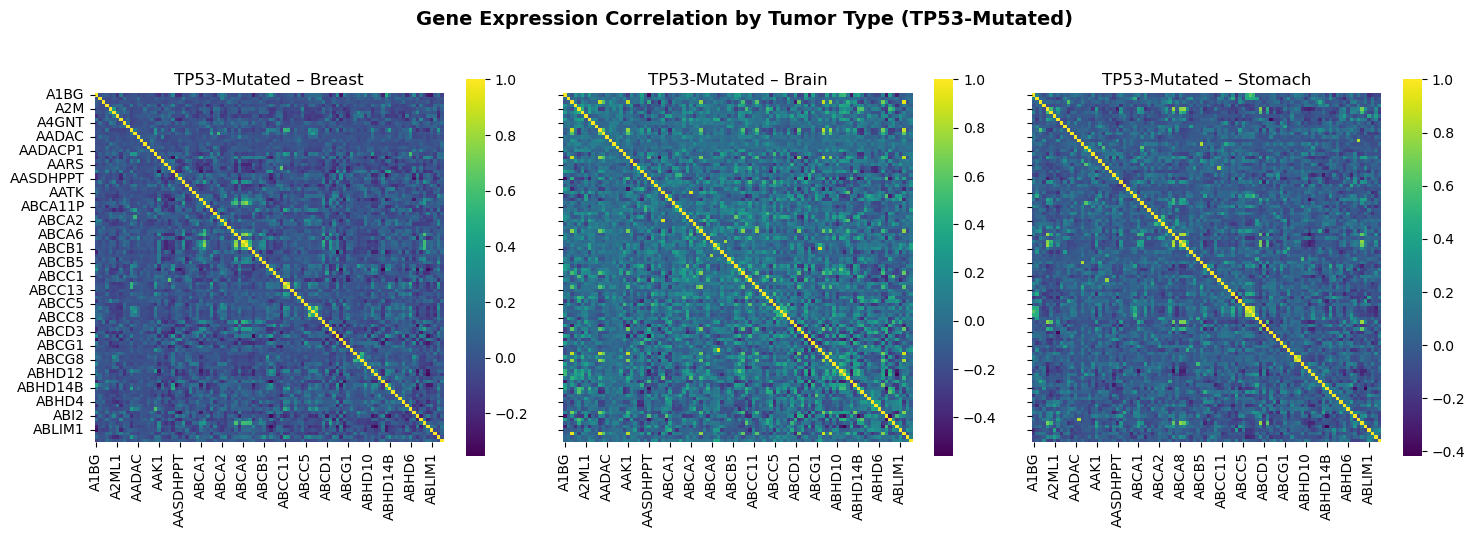

In [139]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

# Plot 1: Breast Invasive
sns.heatmap(
    tcga_filt[(tcga_filt['Mutated'] == 1) & (tcga_filt['Tumor_Type'] == 'breast_invasive')]
    .iloc[:, :-5].iloc[:, :100].corr(),
    ax=axes[0], cmap='viridis', fmt='.1f', square=True
)
axes[0].set_title('TP53-Mutated – Breast')

# Plot 2: Adrenocortical
sns.heatmap(
    tcga_filt[(tcga_filt['Mutated'] == 1) & (tcga_filt['Tumor_Type'] == 'brain')]
    .iloc[:, :-5].iloc[:, :100].corr(),
    ax=axes[1], cmap='viridis', fmt='.1f', square=True
)
axes[1].set_title('TP53-Mutated – Brain')

# Plot 3: Stomach
sns.heatmap(
    tcga_filt[(tcga_filt['Mutated'] == 1) & (tcga_filt['Tumor_Type'] == 'stomach')]
    .iloc[:, :-5].iloc[:, :100].corr(),
    ax=axes[2], cmap='viridis', fmt='.1f', square=True
)
axes[2].set_title('TP53-Mutated – Stomach')

# Figure-level title
fig.suptitle('Gene Expression Correlation by Tumor Type (TP53-Mutated)', fontsize=14, weight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

The outcome of this plot reveals, as expected,  a matrix with mostly weak or zero correlations.

that Most genes are regulated independently
As genes are part of distinct biological pathways (metabolism, immune response, DNA repair), most genes are independelty regulated. so unless two genes are co-regulated (for instance, by the same transcription factor), their expression does not exhibit correlation.

In real transcriptomic data many genes are not expressed in many sample, and measurement noise from rna-seq makes weak patterns even harder to detect. for this reasons, even the correlation betweeen related genes can become harder to detect.

The small bright gene clusters that appear could be instead ribosomal proteins, cell cycle genes, tp53 target genes under stress.